In [2]:
import numpy as np
import matplotlib.pyplot as plt

bounce_times = []
g = 9.81

def initial_velocity(speed, omega):
    return np.array([
        speed * np.cos(omega),
        speed * np.sin(omega)
    ])

def time_to_next_bounce(r, v, R):
    A = 0.25 * g**2
    B = -g * v[1]
    C = v[0]**2 + v[1]**2 - g*r[1]
    D = 2*(r[0]*v[0] + r[1]*v[1])
    E = r[0]**2 + r[1]**2 - R**2

    # Solve polynomial
    coeffs = [A, B, C, D, E]
    roots = np.roots(coeffs)

    # Keep only real, positive roots
    roots = roots[np.isreal(roots)].real
    roots = roots[roots > 1e-8]

    if len(roots) == 0:
        return None

    return min(roots)

def time_to_ground(r, v):
    a, b, c = -0.5*g, v[1], r[1]
    disc = b**2 - 4*a*c
    if disc >= 0:
        t1 = (-b + np.sqrt(disc)) / (2*a)
        t2 = (-b - np.sqrt(disc)) / (2*a)
        t_ground = max(t1, t2)
        return t_ground
    else: None

def reflect_velocity(r, v, e):
    n = r / np.linalg.norm(r)
    vn = np.dot(v, n)
    if abs(vn) < 1e-4:
        vn = (vn) * 100
        vn = np.sign(vn) * 0.01
    theta = np.arccos(abs(vn) / np.linalg.norm(v))

    v_normal = vn * n
    v_tangent = v - v_normal
    return v_tangent - e * v_normal, theta

In [3]:
def simulate(r, R, e, omega, speed):
    r = np.array(r, dtype=float)
    at_ground = False

    segments_x = []
    segments_y = []
    bounce_count = 0
    bounce_times = []
    bounce_points = []
    impact_angles = []

    omega_deg = omega * np.pi / 180
    v = speed * np.array([np.cos(omega_deg), np.sin(omega_deg)])

    while(at_ground == False):
        t = time_to_next_bounce(r, v, R)
        if t is None:
            break
        bounce_times.append(t)

        # Trajectory until impact
        t_vals = np.linspace(0, t, 200)
        segments_x.append(r[0] + v[0]*t_vals)
        segments_y.append(r[1] + v[1]*t_vals - 0.5*g*t_vals**2)

        # Update and record impact point
        r[0] = r[0] + v[0]*t
        r[1] = r[1] + v[1]*t - 0.5*g*t**2

        # Update velocity at impact
        v[1] -= g*t

        bounce_points.append(r.copy())
        bounce_count += 1

        # Find velocity after impact
        v, theta = reflect_velocity(r, v, e)
        impact_angles.append(theta)

    # Escape trajectory after final bounce
    t = time_to_ground(r, v)

    if t is not None:
        t_vals = np.linspace(0, t, 200)
        segments_x.append(r[0] + v[0]*t_vals)
        segments_y.append(r[1] + v[1]*t_vals - 0.5*g*t_vals**2)
        at_ground = True

    trajectory_x = np.concatenate(segments_x)
    trajectory_y = np.concatenate(segments_y)

    return trajectory_x, trajectory_y, bounce_count, bounce_times, bounce_points, impact_angles

Number of bounces: 14


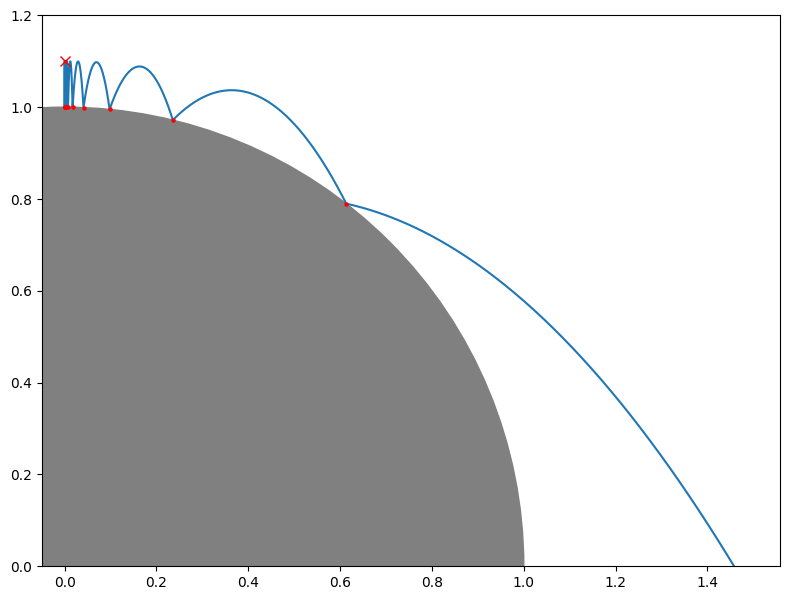

In [4]:
R = 1
r = [0.00001, 1.1*R]
e = 1

traj_x, traj_y, bounces, _, bounce_points, _ = simulate(r, R, e, omega=270, speed=0)
bounce_points = np.array(bounce_points)
print(f"Number of bounces: {bounces}")

plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), R, fill=True, color='grey')
plt.gca().add_patch(circle)
plt.plot(traj_x, traj_y, label=f'Trajectory when d={r[0]}, {bounces} bounces')      #plot trajectory
plt.plot(r[0], r[1], 'x', color='red', ms=7)                                        #plot drop point
plt.scatter(bounce_points[:,0], bounce_points[:,1], color='red', s=5, zorder=2)     #plot impact points
plt.gca().set_aspect('equal', 'box')

max_traj_x, max_traj_y = -np.inf, -np.inf
max_traj_x, max_traj_y = max(max_traj_x, np.max(traj_x)), max(max_traj_y, np.max(traj_y))
plt.xlim(-0.05*R, max_traj_x + 0.1*R)
plt.ylim(0, max_traj_y + 0.1*R)
plt.tight_layout()
plt.show()

Number of bounces for [0.001, 1.1]: 8
Number of bounces for [0.05, 1.1]: 4
Number of bounces for [0.1, 1.1]: 3


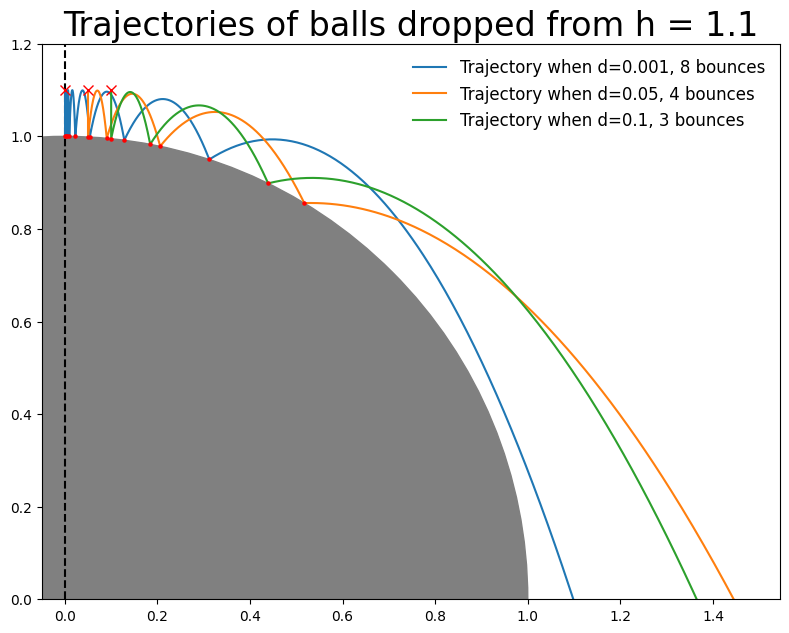

In [5]:
R = 1
r1 = [0.001, 1.1*R]
r2 = [0.05, 1.1*R]
r3 = [0.1, 1.1*R]

plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), R, fill=True, color='grey')
plt.gca().add_patch(circle)
plt.axvline(x=0, color='black', linestyle='--')
max_traj_x, max_traj_y = -np.inf, -np.inf

for r in [r1, r2, r3]:
    traj_x, traj_y, bounces, _, bounce_points, _ = simulate(r, R, e=1, omega=270, speed=0)
    bounce_points = np.array(bounce_points)
    print(f"Number of bounces for {r}: {bounces}")

    plt.plot(traj_x, traj_y, label=f'Trajectory when d={r[0]}, {bounces} bounces')      #plot trajectory
    plt.plot(r[0], r[1], 'x', color='red', ms=7)                                        #plot drop point
    plt.scatter(bounce_points[:,0], bounce_points[:,1], color='red', s=5, zorder=2)     #plot impact points
    plt.gca().set_aspect('equal', 'box')

    max_traj_x, max_traj_y = max(max_traj_x, np.max(traj_x)), max(max_traj_y, np.max(traj_y))

plt.xlim(-0.05*R, max_traj_x + 0.1*R)
plt.ylim(0, max_traj_y + 0.1*R)
plt.title("Trajectories of balls dropped from h = 1.1", fontsize='24')
plt.legend(fontsize='12', frameon=False)
plt.tight_layout()
plt.show()

Number of bounces for [0.01, 1.25]: 4
Number of bounces for [0.01, 1.15]: 5
Number of bounces for [0.01, 1.05]: 8


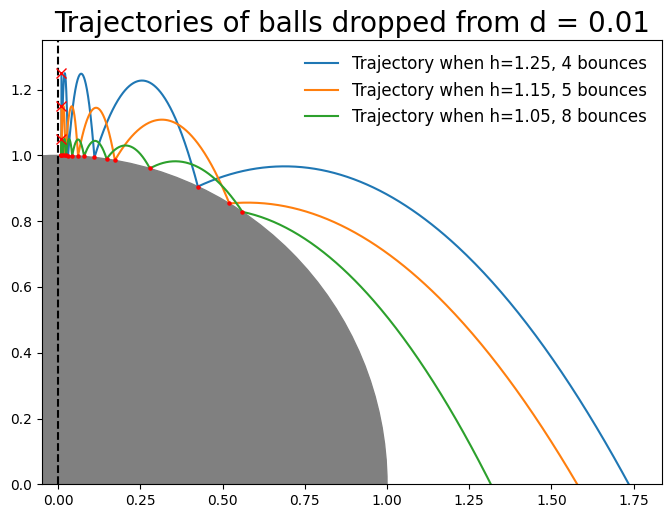

In [6]:
R = 1
r1 = [0.01, 1.25*R]
r2 = [0.01, 1.15*R]
r3 = [0.01, 1.05*R]

plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), R, fill=True, color='grey')
plt.gca().add_patch(circle)
plt.axvline(x=0, color='black', linestyle='--')
max_traj_x, max_traj_y = -np.inf, -np.inf

for r in [r1, r2, r3]:
    traj_x, traj_y, bounces, _, bounce_points, _ = simulate(r, R, e=1, omega=270, speed=0)
    bounce_points = np.array(bounce_points)
    print(f"Number of bounces for {r}: {bounces}")

    plt.plot(traj_x, traj_y, label=f'Trajectory when h={r[1]}, {bounces} bounces')      #plot trajectory
    plt.plot(r[0], r[1], 'x', color='red', ms=7)                                        #plot drop point
    plt.scatter(bounce_points[:,0], bounce_points[:,1], color='red', s=5, zorder=2)     #plot impact points
    plt.gca().set_aspect('equal', 'box')

    max_traj_x, max_traj_y = max(max_traj_x, np.max(traj_x)), max(max_traj_y, np.max(traj_y))

plt.xlim(-0.05*R, max_traj_x + 0.1*R)
plt.ylim(0, max_traj_y + 0.1*R)
plt.title("Trajectories of balls dropped from d = 0.01", fontsize='20')
plt.legend(fontsize='12', frameon=False)
plt.show()

Number of bounces for e=0.95: 4
Number of bounces for e=0.90: 5
Number of bounces for e=0.85: 6
Number of bounces for e=0.80: 7


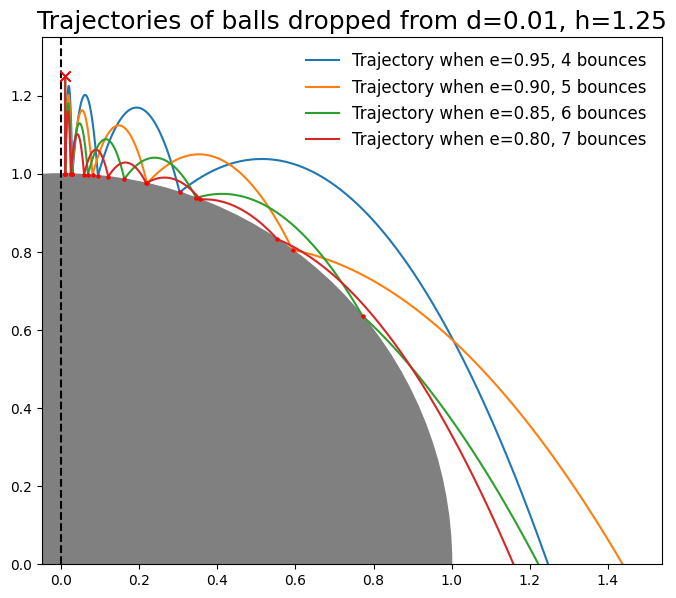

In [7]:
R = 1
r = [0.01, 1.25]

plt.figure(figsize=(8, 8))
circle = plt.Circle((0, 0), R, fill=True, color='grey')
plt.gca().add_patch(circle)
plt.axvline(x=0, color='black', linestyle='--')
max_traj_x, max_traj_y = -np.inf, -np.inf

for e in [0.95, 0.9, 0.85, 0.8]:
    traj_x, traj_y, bounces, _, bounce_points, _ = simulate(r, R, e, omega=270, speed=0)
    bounce_points = np.array(bounce_points)
    print(f"Number of bounces for {e=:.2f}: {bounces}")

    plt.plot(traj_x, traj_y, label=f'Trajectory when {e=:.2f}, {bounces} bounces')      #plot trajectory
    plt.plot(r[0], r[1], 'x', color='red', ms=7)                                        #plot drop point
    plt.scatter(bounce_points[:,0], bounce_points[:,1], color='red', s=5, zorder=2)     #plot impact points
    plt.gca().set_aspect('equal', 'box')

    max_traj_x, max_traj_y = max(max_traj_x, np.max(traj_x)), max(max_traj_y, np.max(traj_y))

plt.xlim(-0.05*R, max_traj_x + 0.1*R)
plt.ylim(0, max_traj_y + 0.1*R)
plt.title("Trajectories of balls dropped from d=0.01, h=1.25", fontsize='18')
plt.legend(fontsize='12', frameon=False)
plt.show()

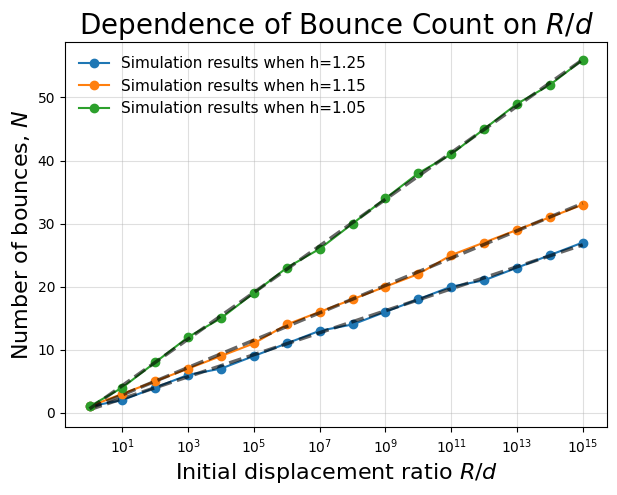

In [8]:
R = 1
e = 1
omega = 270
speed = 0

h_vals = np.array([1.25, 1.15, 1.05])

plt.figure(figsize=(7,5))
for h in h_vals:

    magnitudes = []
    ratios = []
    num_bounces = []

    for magnitude in range(0, 16):
        d = 0.1**magnitude
        r = [d, h]

        magnitudes.append(magnitude)
        ratios.append(R/d)

        traj_x, traj_y, bounces, *_ = simulate(r, R, e, omega, speed)
        num_bounces.append(bounces)

    slope, intercept = np.polyfit(np.log(ratios), num_bounces, 1)
    #print(f"slope = {slope}, intercept = {intercept}")
    plt.semilogx(ratios, num_bounces, 'o-', label=f"Simulation results when h={h:.2f}")
    N_pred = slope * np.log(ratios) + intercept
    plt.semilogx(ratios, N_pred, '--', linewidth=2.5, color='black', alpha=0.6)

plt.title('Dependence of Bounce Count on $R/d$', fontsize='20')
plt.xlabel("Initial displacement ratio $R/d$", fontsize='16')
plt.ylabel("Number of bounces, $N$", fontsize='16')
plt.grid(True, alpha=0.4)
plt.legend(fontsize='11', frameon=False)
plt.show()

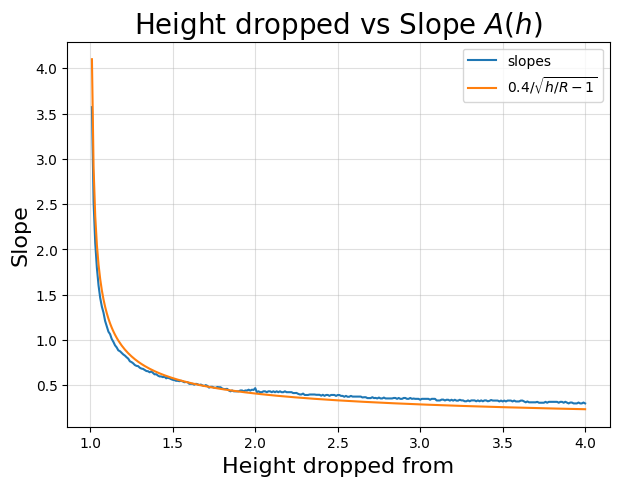

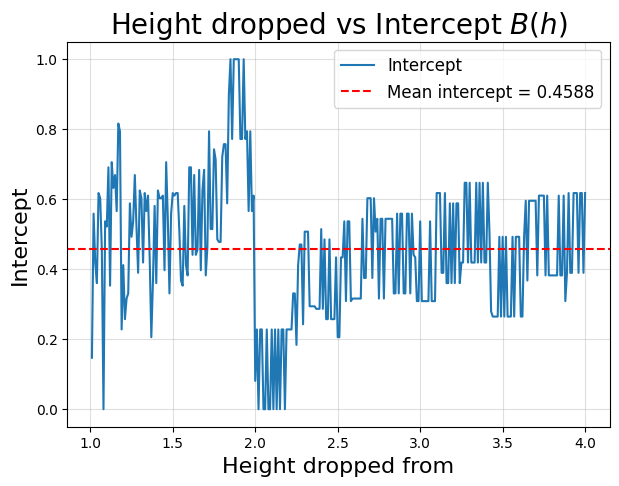

In [32]:
slopes = []
intercepts = []

h_vals = np.arange(1.01, 4.01, 0.01)
for h in h_vals:

    magnitudes = []
    ratios = []
    num_bounces = []

    for magnitude in range(0, 16):
        d = 0.1**magnitude
        r = [d, h]

        magnitudes.append(magnitude)
        ratios.append(R/d)

        traj_x, traj_y, bounces, *_ = simulate(r, R, e, omega, speed)
        num_bounces.append(bounces)

    slope, intercept = np.polyfit(np.log(ratios), num_bounces, 1)
    #print(f"slope = {slope}, intercept = {intercept}")
    slopes.append(slope)
    intercepts.append(intercept)

plt.figure(figsize=(7,5))
plt.plot(h_vals, slopes, label='slopes')
plt.plot(h_vals, 0.4/(np.sqrt(h_vals/R-1)), label=r'$0.4/\sqrt{h/R-1}$')
plt.title(r'Height dropped vs Slope $A(h)$', fontsize='20')
plt.xlabel("Height dropped from", fontsize='16')
plt.ylabel("Slope", fontsize='16')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

avg_intercept = np.mean(intercepts)

plt.figure(figsize=(7,5))
plt.plot(h_vals, intercepts, label="Intercept")
plt.axhline(avg_intercept, linestyle='--', color='red', label=f"Mean intercept = {avg_intercept:.4f}")
plt.title('Height dropped vs Intercept $B(h)$', fontsize='20')
plt.xlabel("Height dropped from", fontsize='16')
plt.ylabel("Intercept", fontsize='16')
plt.grid(True, alpha=0.4)
plt.legend(fontsize='12')
plt.show()

In [10]:
def num_bounces_prediction(d, h, R=1):
  return round(1/(np.e*np.sqrt(h/R-1)) * np.log(R/d) + 0.45)

prediction = num_bounces_prediction(0.0001, 1.1)
print(round(prediction))

11


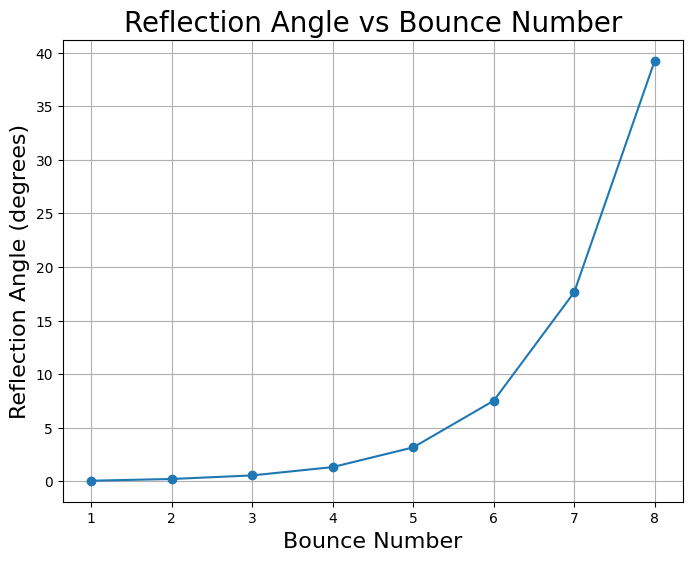

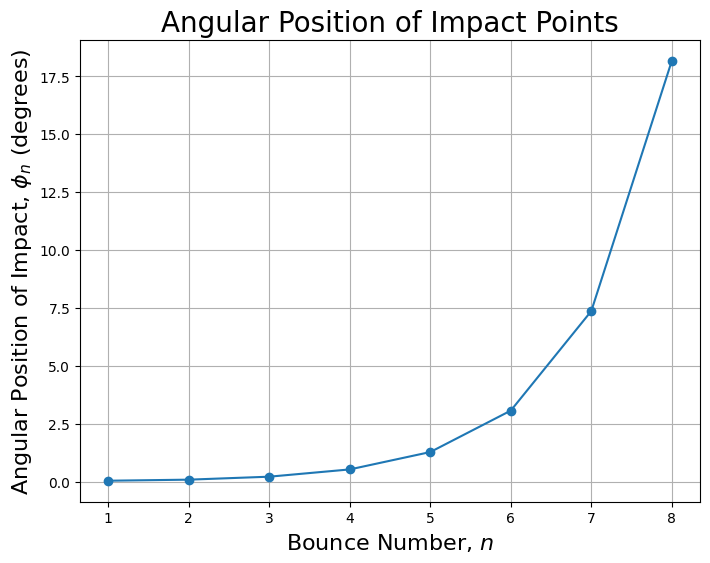

In [18]:
R = 1
r = [0.001, 1.1]
e = 1
omega = 270
speed = 0

num_bounces = []

traj_x, traj_y, bounces, _, bounce_points, impact_angles = simulate(r, R, e, omega, speed)
impact_angles = np.degrees(impact_angles)
num_bounces.append(bounces)

plt.figure(figsize=(8,6))
plt.plot(range(1, len(impact_angles)+1), impact_angles, marker='o')
plt.xlabel("Bounce Number", fontsize='16')
plt.ylabel("Reflection Angle (degrees)", fontsize='16')
plt.title("Reflection Angle vs Bounce Number", fontsize='20')
plt.grid(True)
plt.show()

landing_angles = []
#print(bounce_points)
for i in range(len(bounce_points)):
    angle = np.pi/2 - np.arctan2(bounce_points[i][1], bounce_points[i][0])
    landing_angles.append(np.degrees(angle))

plt.figure(figsize=(8,6))
plt.plot(range(1, len(landing_angles)+1), landing_angles, marker='o')
plt.xlabel("Bounce Number, $n$", fontsize='16')
plt.ylabel("Angular Position of Impact, $\\phi_n$ (degrees)", fontsize='16')
plt.title("Angular Position of Impact Points", fontsize='20')
plt.grid(True)
plt.show()

Number of bounces: 11


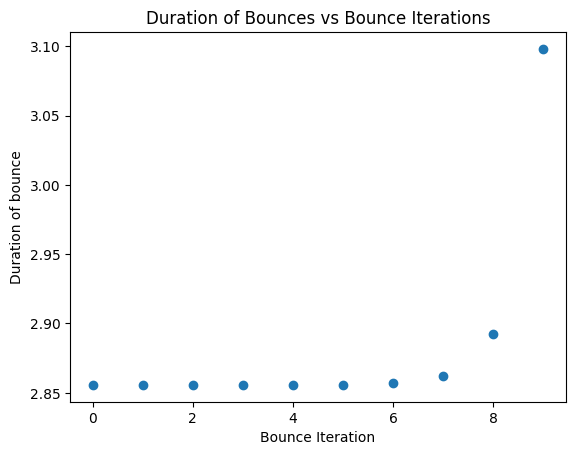

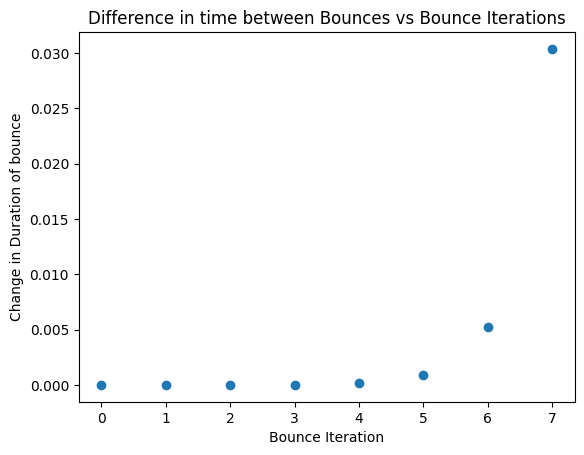

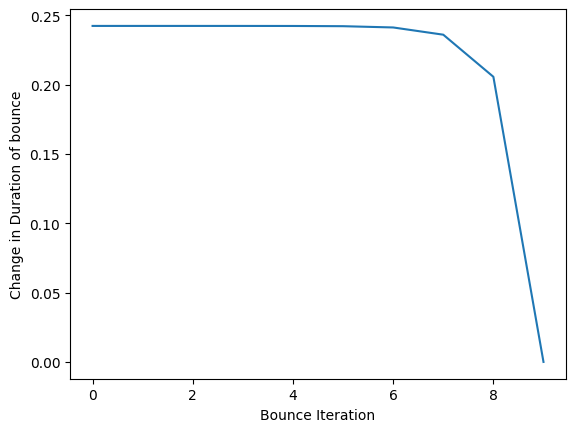

In [12]:
# @title
R = 100
r = [0.01, 110]
e = 1
omega = 270
speed = 0

bounce_times = []
time_differences = []

traj_x, traj_y, bounces, bounce_times, *_ = simulate(r, R, e, omega, speed)
print("Number of bounces:", bounces)
for i in range(len(bounce_times) - 3):
    time_difference = bounce_times[i+2] - bounce_times[i+1]
    time_differences.append(time_difference)

bounce_times.pop(0)
plt.figure()
plt.scatter(range(len(bounce_times)), bounce_times)
plt.title('Duration of Bounces vs Bounce Iterations')
plt.xlabel('Bounce Iteration')
plt.ylabel('Duration of bounce')
plt.show()

plt.figure()
plt.scatter(range(len(time_differences)), time_differences)
plt.title('Difference in time between Bounces vs Bounce Iterations')
plt.xlabel('Bounce Iteration')
plt.ylabel('Change in Duration of bounce')
plt.show()

plt.figure()
plt.plot(range(len(bounce_times)),
             np.abs(bounce_times - bounce_times[-1]))
plt.xlabel('Bounce Iteration')
plt.ylabel('Change in Duration of bounce')
plt.show()

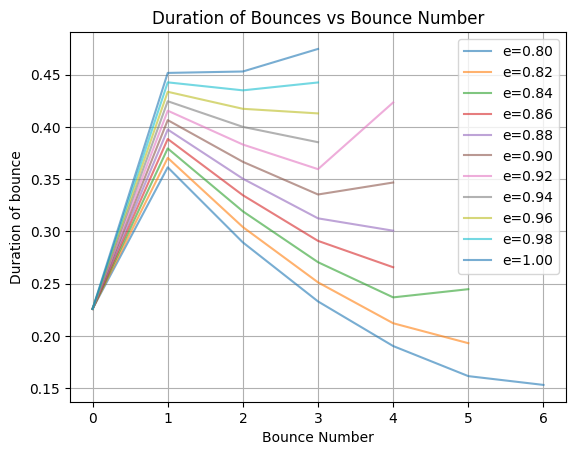

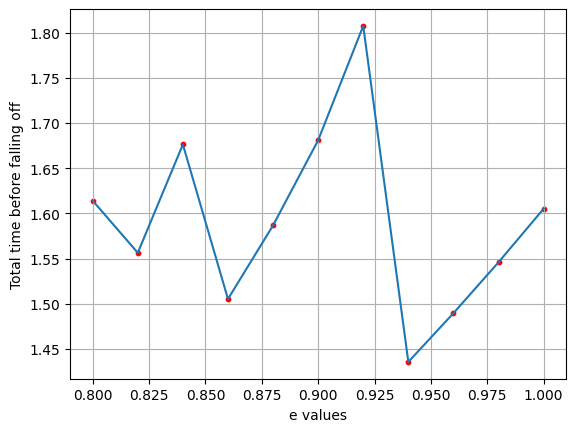

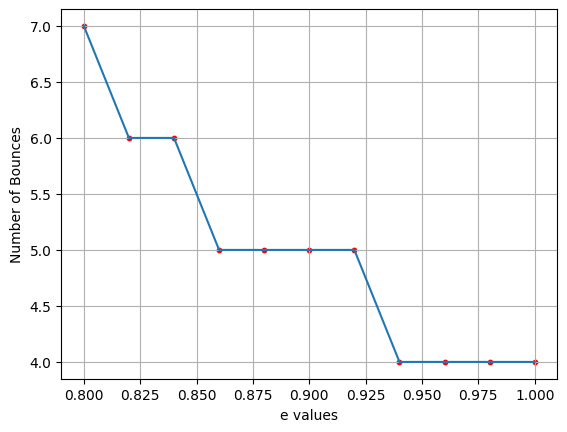

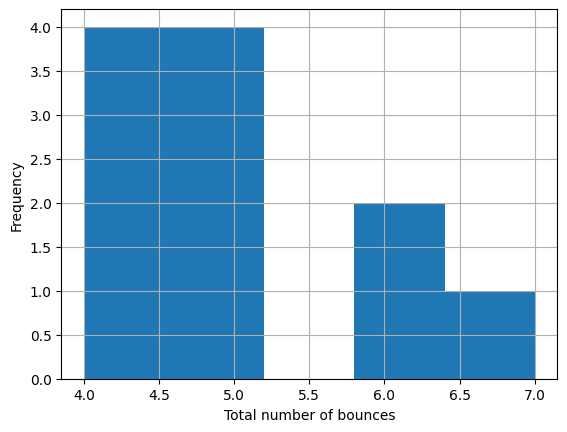

In [21]:
# @title
R = 1
r = [0.01, 1.25]
omega = 270
speed = 0

e_vals = []
total_times = []
num_bounces = []

plt.figure()
for e in np.arange(0.8, 1.01, 0.02):
    bounce_times = []

    traj_x, traj_y, bounces, bounce_times, *_ = simulate(r, R, e, omega, speed)
    #bounce_times.pop(0)

    e_vals.append(e)
    num_bounces.append(bounces)

    total_time = np.sum(bounce_times)
    total_times.append(total_time)

    # print(f"e value: {e:.2f}")
    # print("Number of bounces:", bounces)
    # print("Total time:", total_time)
    # print()
    plt.plot(range(len(bounce_times)), bounce_times, alpha=0.6, label=f"e={e:.2f}")

plt.title('Duration of Bounces vs Bounce Number')
plt.xlabel('Bounce Number')
plt.ylabel('Duration of bounce')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.scatter(e_vals, total_times, s=10, color='red')
plt.plot(e_vals, total_times)
plt.xlabel('e values')
plt.ylabel('Total time before falling off')
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(e_vals, num_bounces, s=10, color='red')
plt.plot(e_vals, num_bounces)
plt.xlabel('e values')
plt.ylabel('Number of Bounces')
plt.grid(True)
plt.show()

plt.figure()
plt.hist(num_bounces, bins='auto')
plt.xlabel('Total number of bounces')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()